# ♻️ Estimativa direta da composição de lotes recicláveis

**Aluno:** Matheus Sousa Marinho · **Matrícula:** 202206132 · **Disciplina:** LIA 1 (2026/2)

## 1. 🎯 Problema e proposta

Um centro de triagem recebe lotes com papel, vidro, metal, plástico, papelão e rejeito. Este
projeto usa uma rede neural para classificar uma foto por vez e transforma as classificações
em uma estimativa simples da composição do lote.

O procedimento é direto: classificar todas as imagens, contar quantas receberam cada classe e
dividir pelo total. Se 35 de 100 imagens forem classificadas como papel, a estimativa será 35%
de papel.

A solução usa o dataset público TrashNet, TensorFlow/Keras e uma EfficientNetB0 pré-treinada.
O notebook é autocontido e pode ser executado no Google Colab sem arquivos auxiliares.

## 2. ⚙️ Configuração

Os parâmetros ficam reunidos abaixo. A semente fixa e o determinismo tornam a execução
reproduzível no mesmo ambiente.

In [1]:
from pathlib import Path

URL_DATASET = (
    "https://huggingface.co/datasets/garythung/trashnet/"
    "resolve/main/dataset-resized.zip"
)
CLASSES_ORIGINAIS = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
CLASSES = ["papelão", "vidro", "metal", "papel", "plástico", "rejeito"]

TAMANHO_IMAGEM = 224
EPOCAS = 30
TAMANHO_BATCH = 32
SEMENTE = 42
FRACAO_VALIDACAO = 0.15
FRACAO_TESTE = 0.15
DETERMINISMO = True

TAMANHO_LOTE = 200
REPETICOES_POR_CENARIO = 30

RAIZ = Path.cwd()
DIR_DADOS = RAIZ / "dados"
DIR_MODELOS = RAIZ / "modelos"
DIR_SAIDAS = RAIZ / "saidas"
for diretorio in (DIR_DADOS, DIR_MODELOS, DIR_SAIDAS):
    diretorio.mkdir(exist_ok=True)

print("diretório de trabalho:", RAIZ)

diretório de trabalho: /Users/m9tzin/Documents/projetos/lia/lia1_2026_2/Entregas - Matheus Marinho/entrega-02-tensorflow


In [2]:
import csv
import os
import sys

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

if DETERMINISMO:
    tf.config.experimental.enable_op_determinism()

tf.keras.utils.set_random_seed(SEMENTE)
AUTOTUNE = tf.data.AUTOTUNE

print("python      ", sys.version.split()[0])
print("tensorflow  ", tf.__version__)
print("dispositivos", [d.device_type for d in tf.config.list_physical_devices()])
print("determinismo", DETERMINISMO)

python       3.12.14
tensorflow   2.21.0
dispositivos ['CPU']
determinismo True


## 3. 🗂️ Dataset público

O TrashNet contém 2.527 fotografias organizadas em seis classes. O arquivo é baixado de um
espelho público no Hugging Face usando `tf.keras.utils.get_file`, sem token ou conta externa.
O download fica em cache na pasta `dados/`.

In [3]:
def localizar_raiz_dataset(base: Path) -> Path:
    for candidato in sorted(base.rglob("*")):
        if not candidato.is_dir() or "__MACOSX" in candidato.parts:
            continue
        if all((candidato / nome).is_dir() for nome in CLASSES_ORIGINAIS):
            return candidato
    raise FileNotFoundError(f"estrutura de classes não encontrada em {base}")


tf.keras.utils.get_file(
    fname="dataset-resized.zip",
    origin=URL_DATASET,
    extract=True,
    cache_dir=str(DIR_DADOS),
    cache_subdir="trashnet",
)
RAIZ_DATASET = localizar_raiz_dataset(DIR_DADOS)
print("dataset:", RAIZ_DATASET)

dataset: /Users/m9tzin/Documents/projetos/lia/lia1_2026_2/Entregas - Matheus Marinho/entrega-02-tensorflow/dados/trashnet/dataset-resized_extracted/dataset-resized


In [4]:
caminhos = []
rotulos = []
for indice, nome_original in enumerate(CLASSES_ORIGINAIS):
    arquivos = sorted((RAIZ_DATASET / nome_original).glob("*.jpg"))
    caminhos.extend(str(arquivo) for arquivo in arquivos)
    rotulos.extend([indice] * len(arquivos))

caminhos = np.asarray(caminhos)
rotulos = np.asarray(rotulos, dtype=int)
N_CLASSES = len(CLASSES)

print(f"{'material':<12}{'imagens':>10}{'proporção':>12}")
print("-" * 34)
for indice, nome in enumerate(CLASSES):
    quantidade = int(np.sum(rotulos == indice))
    print(f"{nome:<12}{quantidade:>10}{quantidade / len(rotulos):>11.1%}")
print("-" * 34)
print(f"{'total':<12}{len(rotulos):>10}")

material       imagens   proporção
----------------------------------
papelão            403      15.9%
vidro              501      19.8%
metal              410      16.2%
papel              594      23.5%
plástico           482      19.1%
rejeito            137       5.4%
----------------------------------
total             2527


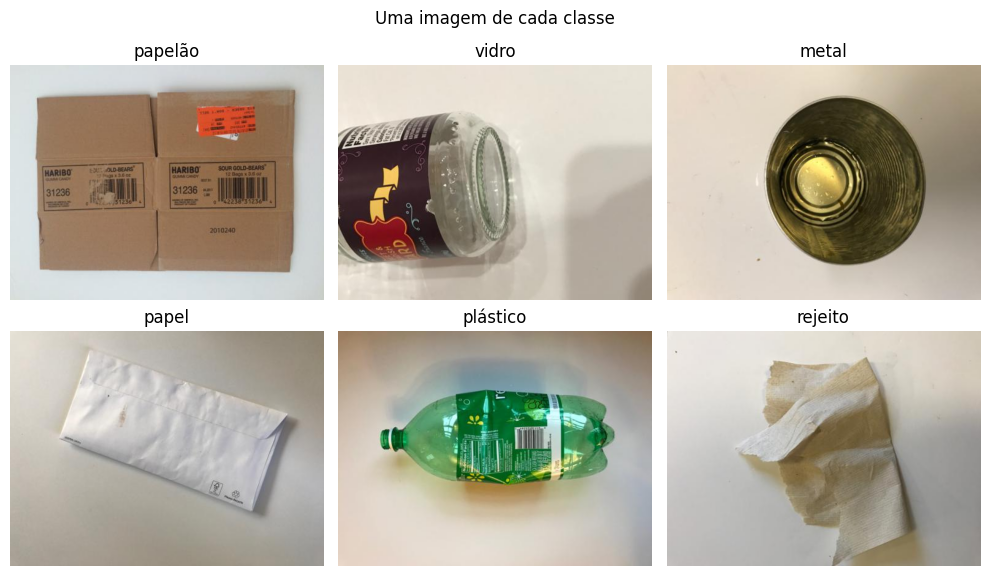

In [5]:
gerador_amostra = np.random.default_rng(SEMENTE)
fig, eixos = plt.subplots(2, 3, figsize=(10, 6))
for classe, eixo in enumerate(eixos.flat):
    indice = gerador_amostra.choice(np.flatnonzero(rotulos == classe))
    eixo.imshow(plt.imread(caminhos[indice]))
    eixo.set_title(CLASSES[classe])
    eixo.axis("off")
plt.suptitle("Uma imagem de cada classe")
plt.tight_layout()
plt.show()

## 4. ✂️ Partição dos dados

A divisão estratificada mantém a proporção das classes. O treino ajusta o modelo, a validação
acompanha o aprendizado e o teste mede o resultado final dentro deste dataset.

In [6]:
indices = np.arange(len(rotulos))
indices_treino, indices_resto = train_test_split(
    indices,
    test_size=FRACAO_VALIDACAO + FRACAO_TESTE,
    stratify=rotulos,
    random_state=SEMENTE,
)
indices_val, indices_teste = train_test_split(
    indices_resto,
    test_size=0.5,
    stratify=rotulos[indices_resto],
    random_state=SEMENTE,
)

rotulos_treino = rotulos[indices_treino]
rotulos_val = rotulos[indices_val]
rotulos_teste = rotulos[indices_teste]

print(f"{'material':<12}{'treino':>9}{'validação':>11}{'teste':>9}")
print("-" * 41)
for indice, nome in enumerate(CLASSES):
    print(
        f"{nome:<12}{np.sum(rotulos_treino == indice):>9}"
        f"{np.sum(rotulos_val == indice):>11}{np.sum(rotulos_teste == indice):>9}"
    )
print("-" * 41)
print(f"{'total':<12}{len(indices_treino):>9}{len(indices_val):>11}{len(indices_teste):>9}")

material       treino  validação    teste
-----------------------------------------
papelão           282         61       60
vidro             350         75       76
metal             287         61       62
papel             416         89       89
plástico          337         72       73
rejeito            96         21       20
-----------------------------------------
total            1768        379      380


## 5. 🤖 Modelo de classificação

A EfficientNetB0 pré-treinada no ImageNet é usada como extrator congelado. Cada imagem vira um
vetor de 1.280 características e apenas uma camada final com softmax é treinada para as seis
classes do TrashNet.

In [7]:
extrator = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(TAMANHO_IMAGEM, TAMANHO_IMAGEM, 3),
)
extrator.trainable = False


@tf.autograph.experimental.do_not_convert
def ler_imagem(caminho):
    imagem = tf.io.decode_jpeg(tf.io.read_file(caminho), channels=3)
    return tf.image.resize(imagem, [TAMANHO_IMAGEM, TAMANHO_IMAGEM])


fotos = (
    tf.data.Dataset.from_tensor_slices(caminhos)
    .map(ler_imagem, num_parallel_calls=AUTOTUNE)
    .batch(64)
    .map(tf.keras.applications.efficientnet.preprocess_input)
    .prefetch(AUTOTUNE)
)
caracteristicas = extrator.predict(fotos, verbose=0)

print(f"{len(caminhos)} imagens -> {caracteristicas.shape[1]} características cada")
print(f"extrator congelado: {extrator.count_params() / 1e6:.1f} milhões de parâmetros")

2527 imagens -> 1280 características cada
extrator congelado: 4.0 milhões de parâmetros


In [8]:
tf.keras.utils.set_random_seed(SEMENTE)
modelo = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(caracteristicas.shape[1],)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(N_CLASSES, activation="softmax"),
    ]
)
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,686 (30.02 KB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
historico = modelo.fit(
    caracteristicas[indices_treino],
    rotulos_treino,
    validation_data=(caracteristicas[indices_val], rotulos_val),
    epochs=EPOCAS,
    batch_size=TAMANHO_BATCH,
    verbose=0,
)
modelo.save(DIR_MODELOS / "cabeca_efficientnetb0.keras")
print(f"treino concluído: {EPOCAS} épocas")

treino concluído: 30 épocas


## 6. 📊 Avaliação do classificador

Acurácia, precisão, recall, F1-score e matriz de confusão mostram onde o classificador acerta
e erra. Essas métricas são calculadas sobre as 380 imagens de teste.

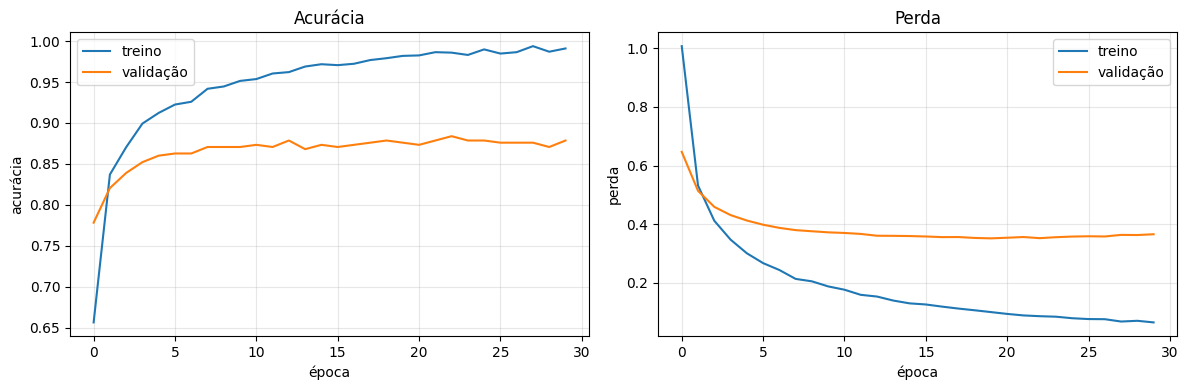

acurácia na validação: 87.86%
acurácia no teste:     90.00%


In [10]:
fig, (esquerda, direita) = plt.subplots(1, 2, figsize=(12, 4))
esquerda.plot(historico.history["accuracy"], label="treino")
esquerda.plot(historico.history["val_accuracy"], label="validação")
esquerda.set(title="Acurácia", xlabel="época", ylabel="acurácia")
esquerda.legend(); esquerda.grid(alpha=0.3)

direita.plot(historico.history["loss"], label="treino")
direita.plot(historico.history["val_loss"], label="validação")
direita.set(title="Perda", xlabel="época", ylabel="perda")
direita.legend(); direita.grid(alpha=0.3)
plt.tight_layout()
plt.show()

probabilidades = modelo.predict(caracteristicas, verbose=0)
predicoes = probabilidades.argmax(axis=1)
predicoes_val = predicoes[indices_val]
predicoes_teste = predicoes[indices_teste]

acuracia_val = float(np.mean(predicoes_val == rotulos_val))
acuracia_teste = float(np.mean(predicoes_teste == rotulos_teste))
print(f"acurácia na validação: {acuracia_val:.2%}")
print(f"acurácia no teste:     {acuracia_teste:.2%}")

In [11]:
print(classification_report(rotulos_teste, predicoes_teste, target_names=CLASSES, digits=3))

              precision    recall  f1-score   support

     papelão      0.964     0.900     0.931        60
       vidro      0.870     0.882     0.876        76
       metal      0.853     0.935     0.892        62
       papel      0.879     0.978     0.926        89
    plástico      0.939     0.849     0.892        73
     rejeito      1.000     0.700     0.824        20

    accuracy                          0.900       380
   macro avg      0.918     0.874     0.890       380
weighted avg      0.904     0.900     0.899       380



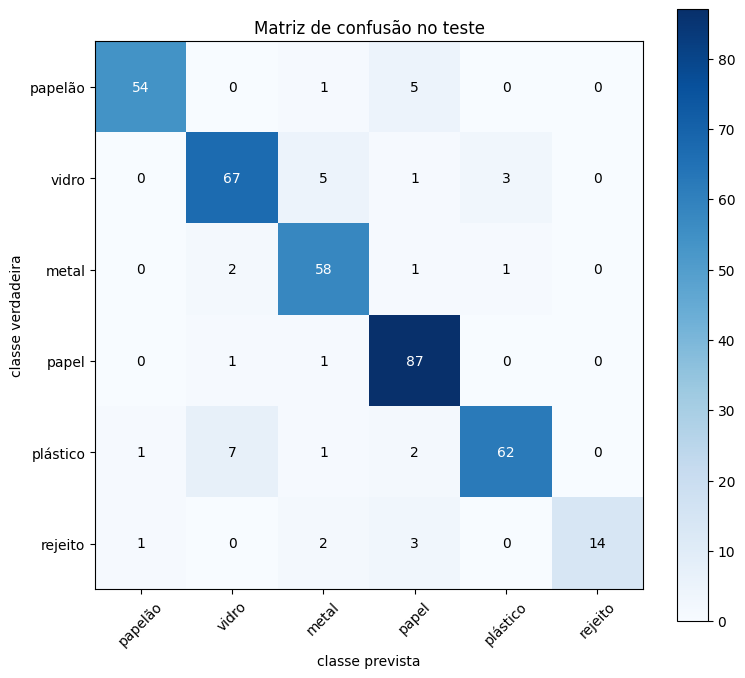

In [12]:
matriz = confusion_matrix(rotulos_teste, predicoes_teste)
plt.figure(figsize=(8, 7))
plt.imshow(matriz, cmap="Blues")
plt.title("Matriz de confusão no teste")
plt.xlabel("classe prevista")
plt.ylabel("classe verdadeira")
plt.xticks(range(N_CLASSES), CLASSES, rotation=45)
plt.yticks(range(N_CLASSES), CLASSES)
plt.colorbar()
limite = matriz.max() / 2
for linha in range(N_CLASSES):
    for coluna in range(N_CLASSES):
        plt.text(
            coluna,
            linha,
            matriz[linha, coluna],
            ha="center",
            va="center",
            color="white" if matriz[linha, coluna] > limite else "black",
        )
plt.tight_layout()
plt.savefig(DIR_SAIDAS / "matriz_confusao.png", dpi=130)
plt.show()

## 7. 🧮 Estimativa direta da composição

Para estimar um lote, contamos as classes previstas e dividimos pelo número de imagens. Como a
bancada conhece as classes verdadeiras, o erro é a diferença absoluta média entre as seis
porcentagens verdadeiras e estimadas.

Não há correção adicional: os erros do classificador aparecem diretamente no resultado. Essa
escolha torna o método fácil de explicar e deixa sua limitação visível.

In [13]:
def calcular_composicao(rotulos_lote: np.ndarray, n_classes: int) -> np.ndarray:
    rotulos_lote = np.asarray(rotulos_lote, dtype=int)
    if rotulos_lote.size == 0:
        raise ValueError("lote vazio")
    return np.bincount(rotulos_lote, minlength=n_classes).astype(float) / rotulos_lote.size


def erro_medio_percentual(verdadeira: np.ndarray, estimada: np.ndarray) -> float:
    return float(100 * np.mean(np.abs(np.asarray(verdadeira) - np.asarray(estimada))))


def montar_lote(
    rotulos_disponiveis: np.ndarray,
    composicao_alvo: np.ndarray,
    tamanho: int,
    gerador: np.random.Generator,
) -> np.ndarray:
    rotulos_disponiveis = np.asarray(rotulos_disponiveis, dtype=int)
    composicao_alvo = np.asarray(composicao_alvo, dtype=float)

    quantidades_exatas = composicao_alvo * tamanho
    quantidades = np.floor(quantidades_exatas).astype(int)
    faltantes = tamanho - int(quantidades.sum())
    if faltantes:
        maiores_restos = np.argsort(-(quantidades_exatas - quantidades))[:faltantes]
        quantidades[maiores_restos] += 1

    partes = []
    for classe, quantidade in enumerate(quantidades):
        if quantidade == 0:
            continue
        disponiveis = np.flatnonzero(rotulos_disponiveis == classe)
        if disponiveis.size == 0:
            raise ValueError(f"classe {classe} sem imagens disponíveis")
        partes.append(gerador.choice(disponiveis, size=quantidade, replace=True))

    indices_lote = np.concatenate(partes)
    gerador.shuffle(indices_lote)
    return indices_lote

In [14]:
CENARIOS = {
    "equilibrado": np.full(6, 1 / 6),
    "dominado por papel": np.array([0.10, 0.10, 0.10, 0.50, 0.10, 0.10]),
    "pouco vidro": np.array([0.196, 0.02, 0.196, 0.196, 0.196, 0.196]),
    "sem metal": np.array([0.20, 0.20, 0.00, 0.20, 0.20, 0.20]),
    "realista": np.array([0.22, 0.15, 0.10, 0.35, 0.13, 0.05]),
    "muito rejeito": np.array([0.12, 0.12, 0.12, 0.12, 0.12, 0.40]),
}

print(f"{'cenário':<22}" + "".join(f"{classe:>11}" for classe in CLASSES))
print("-" * 88)
for nome, composicao in CENARIOS.items():
    print(f"{nome:<22}" + "".join(f"{valor:>10.1%}" for valor in composicao))

cenário                   papelão      vidro      metal      papel   plástico    rejeito
----------------------------------------------------------------------------------------
equilibrado                16.7%     16.7%     16.7%     16.7%     16.7%     16.7%
dominado por papel         10.0%     10.0%     10.0%     50.0%     10.0%     10.0%
pouco vidro                19.6%      2.0%     19.6%     19.6%     19.6%     19.6%
sem metal                  20.0%     20.0%      0.0%     20.0%     20.0%     20.0%
realista                   22.0%     15.0%     10.0%     35.0%     13.0%      5.0%
muito rejeito              12.0%     12.0%     12.0%     12.0%     12.0%     40.0%


In [15]:
rotulos_estoque = np.concatenate([rotulos_val, rotulos_teste])
predicoes_estoque = np.concatenate([predicoes_val, predicoes_teste])
gerador_lotes = np.random.default_rng(SEMENTE)

registros = {}
for nome, alvo in CENARIOS.items():
    erros = []
    lotes = []
    for _ in range(REPETICOES_POR_CENARIO):
        indices_lote = montar_lote(rotulos_estoque, alvo, TAMANHO_LOTE, gerador_lotes)
        verdadeira = calcular_composicao(rotulos_estoque[indices_lote], N_CLASSES)
        estimada = calcular_composicao(predicoes_estoque[indices_lote], N_CLASSES)
        erro = erro_medio_percentual(verdadeira, estimada)
        erros.append(erro)
        lotes.append((verdadeira, estimada))
    registros[nome] = {"erros": np.asarray(erros), "lotes": lotes}

print(f"{'cenário':<22}{'erro médio':>13}{'desvio':>11}")
print("-" * 46)
for nome, registro in registros.items():
    print(f"{nome:<22}{registro['erros'].mean():>12.2f}p{registro['erros'].std():>10.2f}p")
print("-" * 46)
erro_geral = float(np.mean([registro["erros"].mean() for registro in registros.values()]))
print(f"{'média geral':<22}{erro_geral:>12.2f}p")

with open(DIR_SAIDAS / "bancada_cenarios.csv", "w", newline="") as arquivo:
    escritor = csv.writer(arquivo, lineterminator="\n")
    escritor.writerow(["cenario", "erro_medio_pp", "desvio_padrao_pp"])
    for nome, registro in registros.items():
        escritor.writerow([nome, f"{registro['erros'].mean():.4f}", f"{registro['erros'].std():.4f}"])
print()
print("salvo em", DIR_SAIDAS / "bancada_cenarios.csv")

cenário                  erro médio     desvio
----------------------------------------------
equilibrado                   2.80p      0.53p
dominado por papel            1.62p      0.32p
pouco vidro                   3.72p      0.86p
sem metal                     3.77p      0.50p
realista                      1.55p      0.47p
muito rejeito                 5.78p      0.64p
----------------------------------------------
média geral                   3.21p

salvo em /Users/m9tzin/Documents/projetos/lia/lia1_2026_2/Entregas - Matheus Marinho/entrega-02-tensorflow/saidas/bancada_cenarios.csv


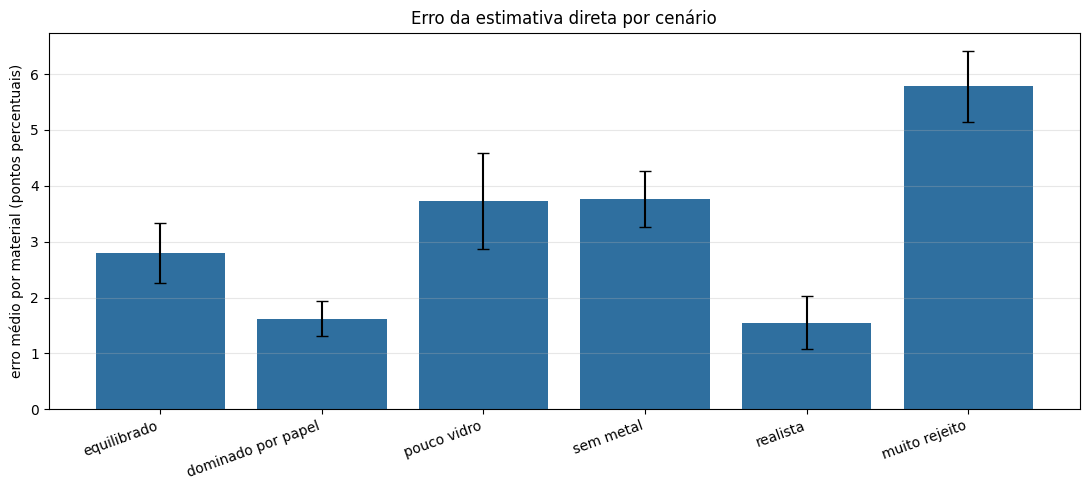

In [16]:
nomes_cenarios = list(registros)
erros_cenarios = [registros[nome]["erros"].mean() for nome in nomes_cenarios]
desvios_cenarios = [registros[nome]["erros"].std() for nome in nomes_cenarios]

plt.figure(figsize=(11, 5))
plt.bar(nomes_cenarios, erros_cenarios, yerr=desvios_cenarios, capsize=4, color="#2f6f9f")
plt.ylabel("erro médio por material (pontos percentuais)")
plt.title("Erro da estimativa direta por cenário")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_SAIDAS / "erro_por_cenario.png", dpi=130)
plt.show()

## 8. 📦 Exemplo de um lote

O exemplo abaixo simula 240 itens em uma composição plausível. A tabela e o gráfico colocam a
verdade simulada e a estimativa lado a lado.

In [17]:
composicao_alvo = CENARIOS["realista"]
indices_exemplo = montar_lote(
    rotulos_teste,
    composicao_alvo,
    tamanho=240,
    gerador=np.random.default_rng(SEMENTE + 1000),
)
verdade_exemplo = calcular_composicao(rotulos_teste[indices_exemplo], N_CLASSES)
estimativa_exemplo = calcular_composicao(predicoes_teste[indices_exemplo], N_CLASSES)
erro_exemplo = erro_medio_percentual(verdade_exemplo, estimativa_exemplo)

print(f"{'material':<12}{'verdade':>12}{'estimativa':>13}{'erro':>10}")
print("-" * 47)
for nome, verdade, estimativa in zip(CLASSES, verdade_exemplo, estimativa_exemplo):
    print(f"{nome:<12}{verdade:>11.1%}{estimativa:>12.1%}{abs(estimativa - verdade) * 100:>9.1f}p")
print("-" * 47)
print(f"erro médio do lote: {erro_exemplo:.2f} pontos percentuais")

with open(DIR_SAIDAS / "relatorio_lote.csv", "w", newline="") as arquivo:
    escritor = csv.writer(arquivo, lineterminator="\n")
    escritor.writerow(["material", "verdade", "estimativa", "erro_pp"])
    for nome, verdade, estimativa in zip(CLASSES, verdade_exemplo, estimativa_exemplo):
        escritor.writerow(
            [nome, f"{verdade:.4f}", f"{estimativa:.4f}", f"{abs(estimativa - verdade) * 100:.4f}"]
        )
print("salvo em", DIR_SAIDAS / "relatorio_lote.csv")

material         verdade   estimativa      erro
-----------------------------------------------
papelão           22.1%       21.2%      0.8p
vidro             15.0%       16.2%      1.3p
metal             10.0%       10.8%      0.8p
papel             35.0%       36.2%      1.3p
plástico          12.9%       12.1%      0.8p
rejeito            5.0%        3.3%      1.7p
-----------------------------------------------
erro médio do lote: 1.11 pontos percentuais
salvo em /Users/m9tzin/Documents/projetos/lia/lia1_2026_2/Entregas - Matheus Marinho/entrega-02-tensorflow/saidas/relatorio_lote.csv


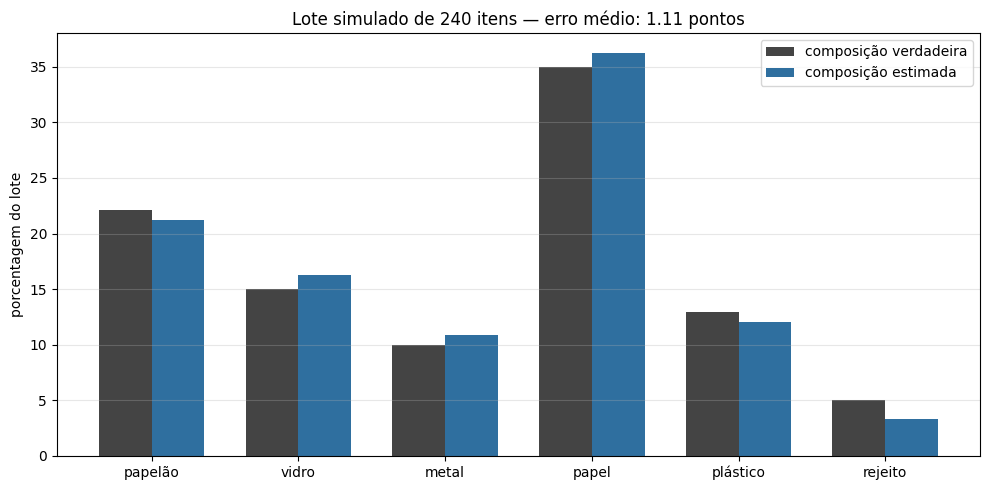

In [18]:
posicoes = np.arange(N_CLASSES)
largura = 0.36
plt.figure(figsize=(10, 5))
plt.bar(posicoes - largura / 2, verdade_exemplo * 100, largura, label="composição verdadeira", color="#444444")
plt.bar(posicoes + largura / 2, estimativa_exemplo * 100, largura, label="composição estimada", color="#2f6f9f")
plt.xticks(posicoes, CLASSES)
plt.ylabel("porcentagem do lote")
plt.title(f"Lote simulado de 240 itens — erro médio: {erro_exemplo:.2f} pontos")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_SAIDAS / "lote_exemplar.png", dpi=130)
plt.show()

In [19]:
melhor_cenario = min(registros, key=lambda nome: registros[nome]["erros"].mean())
pior_cenario = max(registros, key=lambda nome: registros[nome]["erros"].mean())

print("Resumo da avaliação")
print("-------------------")
print(f"acurácia do classificador no teste: {acuracia_teste:.2%}")
print(f"erro médio entre os seis cenários: {erro_geral:.2f} pontos percentuais")
print(f"menor erro: {melhor_cenario} ({registros[melhor_cenario]['erros'].mean():.2f} pontos)")
print(f"maior erro: {pior_cenario} ({registros[pior_cenario]['erros'].mean():.2f} pontos)")
print(f"erro do lote de exemplo: {erro_exemplo:.2f} pontos percentuais")

Resumo da avaliação
-------------------
acurácia do classificador no teste: 90.00%
erro médio entre os seis cenários: 3.21 pontos percentuais
menor erro: realista (1.55 pontos)
maior erro: muito rejeito (5.78 pontos)
erro do lote de exemplo: 1.11 pontos percentuais


## 9. ✅ Conclusão e limitações

A EfficientNetB0 separa bem as seis classes do TrashNet e permite estimar a composição de um
lote por contagem direta. O resultado é simples de interpretar: o erro informa, em pontos
percentuais, quanto as proporções estimadas se afastaram das proporções verdadeiras.

**Limitações:**

- cada fotografia do TrashNet contém um único objeto centralizado e não representa uma esteira real;
- a contagem direta herda os erros do classificador, sem correção adicional;
- os lotes são simulados com reposição, portanto algumas imagens aparecem mais de uma vez;
- a classe rejeito tem somente 137 imagens e produz o cenário mais difícil;
- validação e teste pertencem ao mesmo dataset usado durante o desenvolvimento; os resultados são
  uma avaliação interna, não uma garantia de desempenho em outro ambiente;
- mudanças de iluminação, câmera, sujeira ou sobreposição de objetos podem reduzir bastante a acurácia.

## 📚 Referências

- [TrashNet, dataset original](https://github.com/garythung/trashnet)
- [Espelho público no Hugging Face](https://huggingface.co/datasets/garythung/trashnet)
- [Keras: transfer learning](https://keras.io/guides/transfer_learning/)
- Tan e Le (2019), [EfficientNet](https://arxiv.org/abs/1905.11946)